# Nonparametric Collapsed Gibbs sampling

In [1]:
import numpy as np
from collections import Counter

import matplotlib.pyplot as plt

In [47]:
from nonparametric_collapsed_gibbs import CollapsedGibbsDP
from nonparametric_collapsed_gibbs_multivariante import CollapsedGibbsDP_ND
from gibbs_plots import plot_clustered_1d, plot_clustered_2d

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
FONTSIZE=16
LABELSIZE=0.9*FONTSIZE
LINEWIDTH=2.0
FIGWIDTH=8
ASPECT_RATIO=4/3

plt.rcParams['axes.labelsize'] = FONTSIZE
plt.rcParams['axes.linewidth'] = LINEWIDTH
plt.rcParams['axes.titlesize'] = 1.1*FONTSIZE
plt.rcParams['figure.figsize'] = [FIGWIDTH, FIGWIDTH/ASPECT_RATIO]
plt.rcParams['figure.labelsize'] = FONTSIZE
plt.rcParams['figure.titlesize'] = 1.1*FONTSIZE
plt.rcParams['legend.fancybox'] = False
plt.rcParams['legend.framealpha'] = 1.0
plt.rcParams['legend.fontsize'] = LABELSIZE
plt.rcParams['legend.title_fontsize'] = LABELSIZE
plt.rcParams['patch.linewidth'] = LINEWIDTH
plt.rcParams['lines.linewidth'] = LINEWIDTH
plt.rcParams['xtick.labelsize'] = LABELSIZE
plt.rcParams['ytick.labelsize'] = LABELSIZE
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['figure.autolayout'] = True

plt.rcParams['patch.edgecolor'] = 'black'

In [22]:
DATA_PATH = "../GRBs/GRB_data.txt"
arr = np.loadtxt(DATA_PATH, skiprows=1)
logT90 = arr[:,0]
logHR  = arr[:,2]

In [25]:
import pickle

def save_state_pickle(st, filename):
    """Save `st` to filename using pickle."""
    with open(filename, "wb") as f:
        pickle.dump(st, f, protocol=pickle.HIGHEST_PROTOCOL)

def load_state_pickle(filename):
    """Load state (created by save_state_pickle)."""
    with open(filename, "rb") as f:
        st = pickle.load(f)
    return st

## logT90 (data 1D)

In [105]:
%%time
LOAD   = 1  
alpha  = 1e-10
kappa0 = 0.01

if LOAD == 0:
    # instantiate collapsed Gibbs sampler with weak NIG prior
    rng_gen = np.random.default_rng(1234)
    mid_range = (np.max(logT90) - np.min(logT90))/2.0
    sampler = CollapsedGibbsDP(logT90, alpha=alpha, mu0=mid_range, 
                               kappa0=kappa0, alpha0=2.0, beta0=4.0, 
                               init_clusters=2, rng_gen=rng_gen)
    print("Initial number of clusters:", len(sampler.cluster_ids_))
    sampler.run(1000, verbose=True)
    st = sampler.get_state()
    print("Final num clusters:", len(st['cluster_ids_']))
    print("Counts:", Counter(st['assignment']))

    save_state_pickle(st, f'../chains/assigment_alpha={alpha}_kappa0={kappa0}.pkl')
else:
    st = load_state_pickle(f'../chains/assigment_alpha={alpha}_kappa0={kappa0}.pkl')

CPU times: user 341 µs, sys: 0 ns, total: 341 µs
Wall time: 461 µs


__N_Iter = 1000, alpha=0.1, kappa0=0.1:__ (37min 59s)

    Initial number of clusters: 2
    Iter 100/1000   num_clusters=2   counts={1: 578, 0: 1354}
    Iter 200/1000   num_clusters=2   counts={0: 1329, 1: 603}
    Iter 300/1000   num_clusters=2   counts={1: 593, 0: 1339}
    Iter 400/1000   num_clusters=2   counts={0: 1292, 1: 640}
    Iter 500/1000   num_clusters=2   counts={0: 1312, 1: 620}
    Iter 600/1000   num_clusters=3   counts={2: 552, 0: 982, 1: 398}
    Iter 700/1000   num_clusters=3   counts={1: 469, 0: 1042, 2: 421}
    Iter 800/1000   num_clusters=3   counts={2: 570, 0: 934, 1: 428}
    Iter 900/1000   num_clusters=3   counts={0: 1142, 2: 346, 1: 444}
    Iter 1000/1000   num_clusters=3   counts={2: 533, 0: 969, 1: 430}
    Final num clusters: 3
    Counts: Counter({0: 969, 2: 533, 1: 430})
    Mean Cluster 0  = 3.770 	Sigma Cluster 0 = 0.905
    Mean Cluster 1  = -0.819 	Sigma Cluster 1 = 1.092
    Mean Cluster 2  = 2.349 	Sigma Cluster 2 = 1.231

__N_Iter = 1000, alpha=0.01, kappa0=0.1:__ (30min 59s)

    Initial number of clusters: 2
    Iter 100/1000   num_clusters=2   counts={1: 578, 0: 1354}
    Iter 200/1000   num_clusters=2   counts={0: 1329, 1: 603}
    Iter 300/1000   num_clusters=2   counts={1: 593, 0: 1339}
    Iter 400/1000   num_clusters=2   counts={0: 1292, 1: 640}
    Iter 500/1000   num_clusters=2   counts={0: 1312, 1: 620}
    Iter 600/1000   num_clusters=2   counts={0: 1271, 1: 661}
    Iter 700/1000   num_clusters=2   counts={0: 1319, 1: 613}
    Iter 800/1000   num_clusters=2   counts={0: 1298, 1: 634}
    Iter 900/1000   num_clusters=2   counts={0: 1281, 1: 651}
    Iter 1000/1000   num_clusters=2   counts={0: 1329, 1: 603}
    Final num clusters: 2
    Mean Cluster 0  = 3.538 	Sigma Cluster 0 = 0.996
    Mean Cluster 1  = -0.246 	Sigma Cluster 1 = 1.370

__N_Iter = 1000, alpha=1, kappa0=0.1:__ (1h 19min 3s)

    Initial number of clusters: 2
    Iter 100/1000   num_clusters=4   counts={2: 216, 0: 1071, 1: 512, 8: 133}
    Iter 200/1000   num_clusters=6   counts={1: 560, 0: 686, 14: 173, 21: 55, 2: 456, 22: 2}
    Iter 300/1000   num_clusters=6   counts={14: 163, 0: 908, 1: 552, 2: 270, 15: 35, 16: 4}
    Iter 400/1000   num_clusters=6   counts={0: 732, 1: 535, 14: 569, 2: 75, 18: 19, 19: 2}
    Iter 500/1000   num_clusters=5   counts={0: 726, 14: 652, 1: 502, 18: 50, 23: 2}
    Iter 600/1000   num_clusters=10   counts={18: 157, 14: 840, 24: 103, 42: 198, 1: 294, 0: 94, 29: 117, 41: 118, 44: 8, 45: 3}
    Iter 700/1000   num_clusters=5   counts={14: 825, 42: 428, 29: 260, 1: 262, 18: 157}
    Iter 800/1000   num_clusters=5   counts={42: 690, 14: 788, 43: 21, 1: 313, 29: 120}
    Iter 900/1000   num_clusters=8   counts={14: 1174, 1: 155, 60: 3, 42: 179, 29: 236, 49: 101, 57: 67, 59: 17}
    Iter 1000/1000   num_clusters=7   counts={14: 922, 57: 218, 42: 329, 58: 83, 29: 368, 1: 11, 71: 1}
    Final num clusters: 7
    Mean Cluster 1  = 1.614 	Sigma Cluster 1 = 1.955
    Mean Cluster 14  = 3.534 	Sigma Cluster 14 = 0.900
    Mean Cluster 29  = -1.025 	Sigma Cluster 29 = 1.023
    Mean Cluster 42  = 1.323 	Sigma Cluster 42 = 0.960
    Mean Cluster 57  = 4.174 	Sigma Cluster 57 = 0.846
    Mean Cluster 58  = 3.670 	Sigma Cluster 58 = 0.727
    Mean Cluster 71  = 4.282 	Sigma Cluster 71 = 0.000

======================================================================================

__N_Iter = 1000, alpha=0.1, kappa0=0.01:__ (35min 8s)

    Initial number of clusters: 2
    Iter 100/1000   num_clusters=2   counts={1: 578, 0: 1354}
    Iter 200/1000   num_clusters=2   counts={0: 1329, 1: 603}
    Iter 300/1000   num_clusters=2   counts={1: 591, 0: 1341}
    Iter 400/1000   num_clusters=2   counts={0: 1300, 1: 632}
    Iter 500/1000   num_clusters=2   counts={0: 1312, 1: 620}
    Iter 600/1000   num_clusters=3   counts={2: 553, 0: 982, 1: 397}
    Iter 700/1000   num_clusters=3   counts={2: 530, 0: 1003, 1: 399}
    Iter 800/1000   num_clusters=3   counts={2: 628, 0: 929, 1: 375}
    Iter 900/1000   num_clusters=3   counts={0: 1219, 2: 589, 1: 124}
    Iter 1000/1000   num_clusters=3   counts={0: 1288, 2: 565, 1: 79}
    Final num clusters: 3
    Mean Cluster 0  = 3.581 	Sigma Cluster 0 = 0.970
    Mean Cluster 1  = -1.399 	Sigma Cluster 1 = 0.982
    Mean Cluster 2  = 0.091 	Sigma Cluster 2 = 1.429

__N_Iter = 1000, alpha=1, kappa0=0.01:__ (53min 46s)

    Initial number of clusters: 2
    Iter 100/1000   num_clusters=2   counts={1: 578, 0: 1354}
    Iter 200/1000   num_clusters=2   counts={0: 1328, 1: 604}
    Iter 300/1000   num_clusters=2   counts={1: 584, 0: 1348}
    Iter 400/1000   num_clusters=3   counts={0: 1269, 1: 647, 4: 16}
    Iter 500/1000   num_clusters=3   counts={0: 1296, 1: 589, 2: 47}
    Iter 600/1000   num_clusters=6   counts={2: 235, 0: 912, 5: 346, 1: 335, 6: 94, 8: 10}
    Iter 700/1000   num_clusters=5   counts={2: 265, 0: 834, 6: 169, 5: 346, 1: 318}
    Iter 800/1000   num_clusters=6   counts={5: 562, 0: 747, 7: 8, 6: 326, 1: 216, 2: 73}
    Iter 900/1000   num_clusters=5   counts={0: 1087, 5: 253, 6: 399, 7: 115, 1: 78}
    Iter 1000/1000   num_clusters=4   counts={0: 1244, 5: 142, 7: 389, 6: 157}
    Final num clusters: 4
    Mean Cluster 0  = 3.628 	Sigma Cluster 0 = 0.944
    Mean Cluster 5  = 1.758 	Sigma Cluster 5 = 0.920
    Mean Cluster 6  = 0.800 	Sigma Cluster 6 = 1.112
    Mean Cluster 7  = -0.862 	Sigma Cluster 7 = 1.123

======================================================================================

__N_Iter = 1000, alpha=1e-10, kappa0=0.01, init_cluster=2:__ (28min 20s)

    Initial number of clusters: 2
    Iter 100/1000   num_clusters=2   counts={1: 578, 0: 1354}
    Iter 200/1000   num_clusters=2   counts={0: 1329, 1: 603}
    Iter 300/1000   num_clusters=2   counts={1: 591, 0: 1341}
    Iter 400/1000   num_clusters=2   counts={0: 1300, 1: 632}
    Iter 500/1000   num_clusters=2   counts={0: 1312, 1: 620}
    Iter 600/1000   num_clusters=2   counts={0: 1283, 1: 649}
    Iter 700/1000   num_clusters=2   counts={0: 1326, 1: 606}
    Iter 800/1000   num_clusters=2   counts={0: 1298, 1: 634}
    Iter 900/1000   num_clusters=2   counts={0: 1281, 1: 651}
    Iter 1000/1000   num_clusters=2   counts={0: 1333, 1: 599}
    Final num clusters: 2
    Counts: Counter({0: 1333, 1: 599})
    Mean Cluster 0  = 3.533 	Sigma Cluster 0 = 0.998
    Mean Cluster 1  = -0.261 	Sigma Cluster 1 = 1.362

__N_Iter = 1000, alpha=1e-10, kappa0=0.01, init_cluster=3:__ (37min 20s)

    Initial number of clusters: 3
    Iter 100/1000   num_clusters=3   counts={1: 551, 0: 936, 2: 445}
    Iter 200/1000   num_clusters=3   counts={1: 708, 0: 744, 2: 480}
    Iter 300/1000   num_clusters=3   counts={2: 455, 0: 1052, 1: 425}
    Iter 400/1000   num_clusters=3   counts={0: 1014, 1: 601, 2: 317}
    Iter 500/1000   num_clusters=3   counts={0: 1236, 1: 445, 2: 251}
    Iter 600/1000   num_clusters=3   counts={1: 635, 0: 918, 2: 379}
    Iter 700/1000   num_clusters=3   counts={1: 425, 0: 1049, 2: 458}
    Iter 800/1000   num_clusters=3   counts={1: 598, 0: 751, 2: 583}
    Iter 900/1000   num_clusters=3   counts={0: 1104, 2: 513, 1: 315}
    Iter 1000/1000   num_clusters=3   counts={1: 577, 0: 869, 2: 486}
    Final num clusters: 3
    Counts: Counter({0: 869, 1: 577, 2: 486}
    Mean Cluster 0  = 3.736 	Sigma Cluster 0 = 0.908
    Mean Cluster 1  = 2.803 	Sigma Cluster 1 = 1.229
    Mean Cluster 2  = -0.639 	Sigma Cluster 2 = 1.175

In [106]:
for i in range(len(st['cluster_ids_'])):
    index = st['cluster_ids_'][i]
    print(f"Mean Cluster {index}  = {st['suffstats'][index].mean:.3f} \tSigma Cluster {index} = {np.sqrt(st['suffstats'][index].S/st['suffstats'][index].N):.3f}")

Mean Cluster 0  = 3.533 	Sigma Cluster 0 = 0.998
Mean Cluster 1  = -0.261 	Sigma Cluster 1 = 1.362


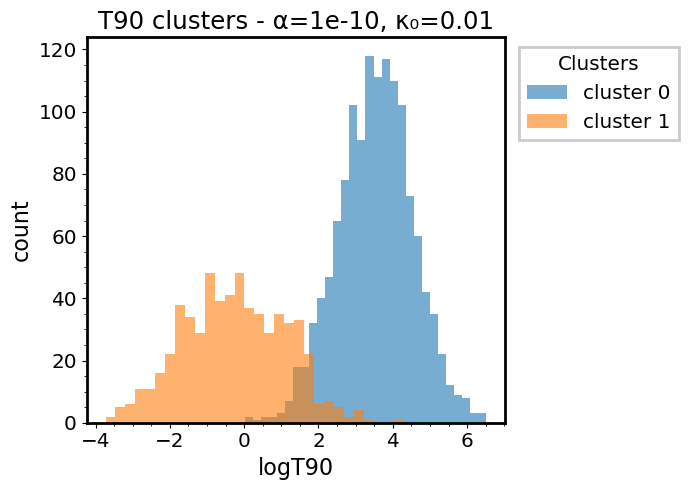

In [107]:
fig1 = plot_clustered_1d(logT90, st['assignment'], title=f"T90 clusters - α={alpha}, κ₀={kappa0}")
plt.savefig(f'../figure/gibbs_sampling/T90_cluster_alpha={alpha}_kappa0={kappa0}.png', dpi=300, bbox_inches='tight')
plt.savefig(f'../figure/gibbs_sampling/T90_cluster_alpha={alpha}_kappa0={kappa0}.pdf', dpi=300, bbox_inches='tight')
plt.show()

Con alpha=1 vengono creati molti cluster; il comportamento è probabilmente dovuto al termine della t-student, dove i valori lontani de cluster ricadono sulle code della distribuzione (che avendo un numero relativamente elevato si cmoporta come una normale, quindi con code che tendono più velocemente a 0 rispetto al t-student). Questo comporta ad un valore di $f_k(x_i)$ molto basso per valori lontani dal centro del cluster. Invece la prior predictive, che corrisponde ad un t-student con i parametri $\alpha_0$, $\beta_0$, $\kappa_0$ e $\mu_0$, pur essendo debolmente informativa rimane superiore ai valori di $f_k(x_i)$ nelle code. La prior predictive è poco informativa perché nel migliore dei casi $\sigma_k \approx 1$ (valore visibile nella distribuzione Inverse Gamma con $\alpha_0=2$ e $\beta_0=4$) il quale corrisponde ad un estrazione di $\mu_k$ in $\mathcal{N}(\mu_k|\mu_0, \sigma_k/\kappa_0 \approx 10)$, cioè con una sigma che equivale a quasi la totalità del range di dati, rendendo la distribuzione praticamente piatta con valori bassi di probabilità.

Riprovare con $\kappa_0=0.01$ per vedere se il problema persiste. Il valore basso di $\kappa_0$ implica una distribuzione di $\mathcal{N}(\mu_k|\mu_0, \sigma_k/\kappa_0)$ molto schiacciata e con valori di probabilità molto bassi (non dovrebbe superare i valori delle code di $f_k(x_i)$. Provato con $\kappa_0=0.01$, ma il problema persiste... causa ignota

## logT90 - logHR (Multidimensional data)

In [23]:
data_2D = np.array([logT90,logHR]).T
data_2D.shape

(1932, 2)

In [96]:
%%time
LOAD   = 1  
alpha  = 1e-10
kappa0 = 0.01

if LOAD == 0:
    # instantiate collapsed Gibbs sampler with weak NIG prior
    rng_gen = np.random.default_rng(1234)
    mid_range = np.array([(np.max(data_2D[:,0]) - np.min(data_2D[:,0]))/2.0, 
                          (np.max(data_2D[:,1]) - np.min(data_2D[:,1]))/2.0])
    sampler = CollapsedGibbsDP_ND(data_2D, alpha=alpha, mu0=mid_range, 
                               kappa0=kappa0, nu0=4, Lambda0=8.0*np.eye(2), 
                               init_clusters=2, rng_gen=rng_gen)
    print("Initial number of clusters:", len(sampler.cluster_ids_))
    sampler.run(1000, verbose=True)
    st = sampler.get_state()
    print("Final num clusters:", len(st['cluster_ids_']))
    print("Counts:", Counter(st['assignment']))

    save_state_pickle(st, f'../chains/assigment_2D_alpha={alpha}_kappa0={kappa0}.pkl')
else:
    st = load_state_pickle(f'../chains/assigment_2D_alpha={alpha}_kappa0={kappa0}.pkl')

CPU times: user 702 µs, sys: 0 ns, total: 702 µs
Wall time: 633 µs


__N_Iter = 1000, alpha=0.1, kappa0=0.1:__ (11min 9s)

    Initial number of clusters: 2
    Iter 100/1000   num_clusters=4   counts={1: 197, 0: 1203, 3: 491, 4: 41}
    Iter 200/1000   num_clusters=4   counts={0: 1248, 3: 530, 4: 70, 1: 84}
    Iter 300/1000   num_clusters=4   counts={3: 529, 0: 1270, 1: 115, 4: 18}
    Iter 400/1000   num_clusters=4   counts={0: 1272, 1: 152, 3: 494, 4: 14}
    Iter 500/1000   num_clusters=4   counts={0: 1275, 3: 578, 1: 62, 4: 17}
    Iter 600/1000   num_clusters=4   counts={0: 1149, 3: 509, 1: 192, 4: 82}
    Iter 700/1000   num_clusters=4   counts={0: 1276, 4: 56, 3: 515, 1: 85}
    Iter 800/1000   num_clusters=4   counts={0: 1207, 4: 63, 3: 534, 1: 128}
    Iter 900/1000   num_clusters=4   counts={0: 1259, 3: 487, 4: 97, 1: 89}
    Iter 1000/1000   num_clusters=4   counts={0: 1299, 3: 524, 1: 91, 4: 18}
    Final num clusters: 4
    Counts: Counter({0: 1299, 3: 524, 1: 91, 4: 18})
    Cluster 0  N=1299  Mean=[3.532 0.217]  Std=[1.011 0.381]
    Cluster 1  N=91  Mean=[ 2.279 -0.02 ]  Std=[1.229 0.943]
    Cluster 3  N=524  Mean=[-0.422  0.549]  Std=[1.241 0.534]
    Cluster 4  N=18  Mean=[-1.17   2.162]  Std=[1.651 0.628]

__N_Iter = 1000, alpha=0.01, kappa0=0.1:__ (9min 53s)

    Initial number of clusters: 2
    Iter 100/1000   num_clusters=3   counts={1: 197, 0: 1269, 2: 466}
    Iter 200/1000   num_clusters=3   counts={0: 1288, 2: 543, 1: 101}
    Iter 300/1000   num_clusters=3   counts={2: 494, 0: 1305, 1: 133}
    Iter 400/1000   num_clusters=4   counts={0: 1275, 1: 103, 2: 541, 3: 13}
    Iter 500/1000   num_clusters=3   counts={0: 1305, 2: 530, 1: 97}
    Iter 600/1000   num_clusters=3   counts={0: 1247, 2: 485, 1: 200}
    Iter 700/1000   num_clusters=3   counts={0: 1283, 2: 462, 1: 187}
    Iter 800/1000   num_clusters=3   counts={0: 1256, 2: 472, 1: 204}
    Iter 900/1000   num_clusters=3   counts={0: 1260, 1: 100, 2: 572}
    Iter 1000/1000   num_clusters=3   counts={0: 1339, 1: 77, 2: 516}
    Final num clusters: 3
    Counts: Counter({0: 1339, 2: 516, 1: 77})
    Cluster 0  N=1339  Mean=[3.511 0.216]  Std=[1.015 0.398]
    Cluster 1  N=77  Mean=[0.573 0.452]  Std=[1.988 1.282]
    Cluster 2  N=516  Mean=[-0.373  0.547]  Std=[1.268 0.554]

__N_Iter = 1000, alpha=1, kappa0=0.1:__ (13min 9s)

    Initial number of clusters: 2
    Iter 100/1000   num_clusters=3   counts={1: 464, 0: 1286, 3: 182}
    Iter 200/1000   num_clusters=5   counts={0: 1270, 1: 478, 5: 79, 3: 102, 6: 3}
    Iter 300/1000   num_clusters=4   counts={1: 550, 0: 1284, 5: 85, 3: 13}
    Iter 400/1000   num_clusters=4   counts={0: 1257, 1: 581, 5: 82, 6: 12}
    Iter 500/1000   num_clusters=4   counts={0: 1275, 1: 575, 5: 66, 6: 16}
    Iter 600/1000   num_clusters=4   counts={0: 1160, 1: 482, 5: 227, 6: 63}
    Iter 700/1000   num_clusters=4   counts={0: 1300, 6: 234, 1: 353, 5: 45}
    Iter 800/1000   num_clusters=4   counts={0: 1195, 7: 69, 6: 163, 1: 505}
    Iter 900/1000   num_clusters=4   counts={0: 1248, 1: 493, 7: 85, 6: 106}
    Iter 1000/1000   num_clusters=4   counts={0: 1311, 1: 552, 6: 58, 9: 11}
    Final num clusters: 4
    Counts: Counter({0: 1311, 1: 552, 6: 58, 9: 11})
    Cluster 0  N=1311  Mean=[3.536 0.212]  Std=[1.006 0.386]
    Cluster 1  N=552  Mean=[-0.293  0.566]  Std=[1.387 0.558]
    Cluster 6  N=58  Mean=[ 1.637 -0.185]  Std=[1.249 0.994]
    Cluster 9  N=11  Mean=[-1.372  2.395]  Std=[1.603 0.578]

=======================================================================================

__N_Iter = 1000, alpha=0.1, kappa0=0.01:__ (9min 50s)

    Initial number of clusters: 2
    Iter 100/1000   num_clusters=3   counts={1: 200, 0: 1269, 2: 463}
    Iter 200/1000   num_clusters=3   counts={0: 1288, 2: 543, 1: 101}
    Iter 300/1000   num_clusters=3   counts={2: 461, 0: 1298, 1: 173}
    Iter 400/1000   num_clusters=4   counts={0: 1275, 1: 103, 2: 541, 3: 13}
    Iter 500/1000   num_clusters=3   counts={0: 1303, 2: 514, 1: 115}
    Iter 600/1000   num_clusters=3   counts={0: 1241, 2: 483, 1: 208}
    Iter 700/1000   num_clusters=3   counts={0: 1298, 2: 463, 1: 171}
    Iter 800/1000   num_clusters=3   counts={0: 1250, 2: 444, 1: 238}
    Iter 900/1000   num_clusters=3   counts={0: 1284, 1: 116, 2: 532}
    Iter 1000/1000   num_clusters=3   counts={0: 1347, 1: 69, 2: 516}
    Final num clusters: 3
    Counts: Counter({0: 1347, 2: 516, 1: 69})
    Cluster 0  N=1347  Mean=[3.5   0.216]  Std=[1.024 0.399]
    Cluster 1  N=69  Mean=[0.458 0.48 ]  Std=[2.057 1.339]
    Cluster 2  N=516  Mean=[-0.373  0.547]  Std=[1.268 0.554]

__N_Iter = 1000, alpha=0.01, kappa0=0.01:__ (8min 30s)

    Initial number of clusters: 2
    Iter 100/1000   num_clusters=2   counts={1: 647, 0: 1285}
    Iter 200/1000   num_clusters=2   counts={0: 1260, 1: 672}
    Iter 300/1000   num_clusters=2   counts={1: 617, 0: 1315}
    Iter 400/1000   num_clusters=3   counts={0: 1277, 1: 537, 2: 118}
    Iter 500/1000   num_clusters=3   counts={0: 1295, 1: 507, 2: 130}
    Iter 600/1000   num_clusters=3   counts={0: 1221, 2: 414, 1: 297}
    Iter 700/1000   num_clusters=3   counts={0: 1284, 2: 188, 1: 460}
    Iter 800/1000   num_clusters=3   counts={0: 1224, 2: 174, 1: 534}
    Iter 900/1000   num_clusters=3   counts={0: 1269, 2: 201, 1: 462}
    Iter 1000/1000   num_clusters=3   counts={0: 1340, 1: 461, 2: 131}
    Final num clusters: 3
    Counts: Counter({0: 1340, 1: 461, 2: 131})
    Cluster 0  N=1340  Mean=[3.506 0.212]  Std=[1.022 0.395]
    Cluster 1  N=461  Mean=[-0.467  0.566]  Std=[1.268 0.482]
    Cluster 2  N=131  Mean=[0.541 0.465]  Std=[1.678 1.161]

__N_Iter = 1000, alpha=1, kappa0=0.01:__ (11min 57s)

    Initial number of clusters: 2
    Iter 100/1000   num_clusters=4   counts={1: 83, 0: 1282, 3: 560, 5: 7}
    Iter 200/1000   num_clusters=4   counts={0: 1254, 3: 535, 5: 50, 1: 93}
    Iter 300/1000   num_clusters=4   counts={3: 540, 0: 1307, 1: 81, 5: 4}
    Iter 400/1000   num_clusters=4   counts={0: 1202, 1: 186, 3: 444, 5: 100}
    Iter 500/1000   num_clusters=4   counts={0: 1276, 3: 543, 1: 96, 5: 17}
    Iter 600/1000   num_clusters=4   counts={0: 1161, 3: 518, 1: 193, 5: 60}
    Iter 700/1000   num_clusters=4   counts={0: 1278, 3: 497, 1: 138, 5: 19}
    Iter 800/1000   num_clusters=4   counts={0: 1203, 5: 67, 3: 536, 1: 126}
    Iter 900/1000   num_clusters=4   counts={0: 1261, 3: 491, 5: 98, 1: 82}
    Iter 1000/1000   num_clusters=4   counts={0: 1296, 3: 533, 1: 88, 5: 15}
    Final num clusters: 4
    Counts: Counter({0: 1296, 3: 533, 1: 88, 5: 15})
    Cluster 0  N=1296  Mean=[3.535 0.216]  Std=[1.008 0.38 ]
    Cluster 1  N=88  Mean=[2.33  0.075]  Std=[1.192 1.002]
    Cluster 3  N=533  Mean=[-0.395  0.544]  Std=[1.275 0.551]
    Cluster 5  N=15  Mean=[-1.508  1.969]  Std=[1.156 0.986]

=======================================================================================

__N_Iter = 1000, alpha=1e-10, kappa0=0.01, init_cluster=2:__ (7min 9s)

    Initial number of clusters: 2
    Iter 100/1000   num_clusters=2   counts={1: 647, 0: 1285}
    Iter 200/1000   num_clusters=2   counts={0: 1260, 1: 672}
    Iter 300/1000   num_clusters=2   counts={1: 617, 0: 1315}
    Iter 400/1000   num_clusters=2   counts={0: 1234, 1: 698}
    Iter 500/1000   num_clusters=2   counts={0: 1295, 1: 637}
    Iter 600/1000   num_clusters=2   counts={1: 731, 0: 1201}
    Iter 700/1000   num_clusters=2   counts={0: 1269, 1: 663}
    Iter 800/1000   num_clusters=2   counts={0: 1213, 1: 719}
    Iter 900/1000   num_clusters=2   counts={0: 1213, 1: 719}
    Iter 1000/1000   num_clusters=2   counts={0: 1312, 1: 620}
    Final num clusters: 2
    Counts: Counter({0: 1312, 1: 620})
    Cluster 0  N=1312  Mean=[3.553 0.228]  Std=[0.987 0.402]
    Cluster 1  N=620  Mean=[-0.174  0.495]  Std=[1.427 0.692]

__N_Iter = 1000, alpha=1e-10, kappa0=0.01, init_cluster=3:__ (8min 57s)

    Initial number of clusters: 3
    Iter 100/1000   num_clusters=3   counts={1: 99, 0: 1285, 2: 548}
    Iter 200/1000   num_clusters=3   counts={0: 1288, 2: 543, 1: 101}
    Iter 300/1000   num_clusters=3   counts={2: 461, 0: 1298, 1: 173}
    Iter 400/1000   num_clusters=3   counts={0: 1272, 1: 124, 2: 536}
    Iter 500/1000   num_clusters=3   counts={0: 1303, 2: 482, 1: 147}
    Iter 600/1000   num_clusters=3   counts={0: 1241, 2: 483, 1: 208}
    Iter 700/1000   num_clusters=3   counts={0: 1298, 2: 463, 1: 171}
    Iter 800/1000   num_clusters=3   counts={0: 1250, 2: 444, 1: 238}
    Iter 900/1000   num_clusters=3   counts={0: 1284, 1: 116, 2: 532}
    Iter 1000/1000   num_clusters=3   counts={0: 1347, 1: 69, 2: 516}
    Final num clusters: 3
    Counts: Counter({0: 1347, 2: 516, 1: 69})
    Cluster 0  N=1347  Mean=[3.5   0.216]  Std=[1.024 0.399]
    Cluster 1  N=69  Mean=[0.458 0.48 ]  Std=[2.057 1.339]
    Cluster 2  N=516  Mean=[-0.373  0.547]  Std=[1.268 0.554]

In [97]:
for idx in st['cluster_ids_']:
    ss = st['suffstats'][idx]
    if ss.N == 0:
        print(f"Cluster {idx}: empty (N=0)"); continue
    mean = ss.mean                          # shape (D,)
    std = np.sqrt(np.diag(ss.S / ss.N))    # marginal std per dimension
    print(f"Cluster {idx}  N={ss.N}  Mean={np.array2string(mean, precision=3)}  Std={np.array2string(std, precision=3)}")

Cluster 0  N=1312  Mean=[3.553 0.228]  Std=[0.987 0.402]
Cluster 1  N=620  Mean=[-0.174  0.495]  Std=[1.427 0.692]


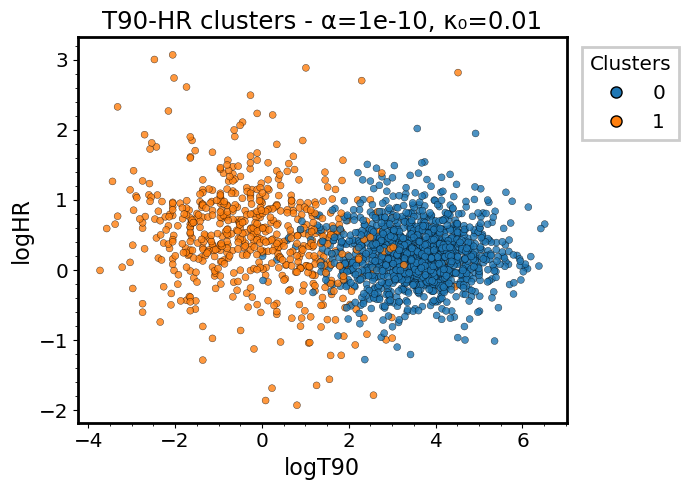

In [98]:
fig1 = plot_clustered_2d(data_2D, st['assignment'], title=f"T90-HR clusters - α={alpha}, κ₀={kappa0}")
plt.savefig(f'../figure/gibbs_sampling/T90_HR_cluster_alpha={alpha}_kappa0={kappa0}.png', dpi=300, bbox_inches='tight')
plt.savefig(f'../figure/gibbs_sampling/T90_HR_cluster_alpha={alpha}_kappa0={kappa0}.pdf', dpi=300, bbox_inches='tight')
plt.show()